# Phase 1 — Preprocessing, Filtering, and Cleaning Reports 

This phase constructs the core text corpus used throughout the project. Starting from raw sustainability reports in PDF format, we extract and filter environmentally relevant passages to create a structured dataset for downstream analysis.


### Data Sources

We use 2023–2025 sustainability reports from the following brands:

- **Fashion:** H&M, Zara (Inditex), Patagonia, Eileen Fisher, Reformation, Everlane, Kering, Lululemon, Puma, Ralph Lauren, Shein
- **Clean beauty:** L'Oréal, Sephora, Lush, L'Occitane, Unilever

All reports are sourced from company investor relations pages and stored in `data/raw/`.

### Pipeline Overview

The preprocessing pipeline transforms raw PDFs into model-ready text passages:

**PDF → sentence segmentation → rolling windows → ClimateBERT filtering → `passages.jsonl`**

Sentence extraction results are cached per brand in `data/extracted/sentences_cache/` so re-runs skip already-parsed PDFs.

In [1]:
import json
import re
from pathlib import Path
from collections import defaultdict

import pymupdf4llm
import nltk
import pandas as pd
from transformers import pipeline
from codecarbon import EmissionsTracker

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize

In [2]:

# configurations 
ROOT      = Path('..').resolve()
RAW_DIR   = ROOT / 'data' / 'raw'
OUT_DIR   = ROOT / 'data' / 'extracted'
OUT_DIR.mkdir(parents=True, exist_ok=True)

CACHE_DIR = OUT_DIR / 'sentences_cache'
CACHE_DIR.mkdir(parents=True, exist_ok=True)

CARBON_DIR = ROOT / 'results' / 'carbon'
CARBON_DIR.mkdir(parents=True, exist_ok=True)

WINDOW_SIZE = 5    # sentences per passage — shorter = one claim per window, less topic mixing
STRIDE      = 3    # overlap stride (Window 1: 1–3, Window 2: 2–5, Window 3: 4–7 …)
MIN_SENTS   = 3    # drop windows shorter than this (ignores footers or table of contents)

# the most recent reports released 
BRANDS = [
    # --- fashion ---
    {"file": "hm-2025.pdf",          "brand": "H&M",           "industry": "fashion",      "role": "greenwashing"},
    # ^ well-documented: Norwegian Consumer Authority ruling, vague conscious collection claims

    {"file": "zara-2025.pdf",        "brand": "Zara",          "industry": "fashion",      "role": "greenwashing"},
    # ^ Inditex repeatedly flagged for unverifiable sustainability targets

    {"file": "shein-2024.pdf",       "brand": "Shein",         "industry": "fashion",      "role": "greenwashing"},
    # ^ clearest greenwashing case in dataset — worst emissions, weakest claims

    {"file": "kering-2025.pdf",      "brand": "Kering",        "industry": "fashion",      "role": "greenwashing"},
    # ^ luxury greenwashing pattern — high-end positioning obscures supply chain issues

    {"file": "lululemon-2024.pdf",   "brand": "Lululemon",     "industry": "fashion",      "role": "greenwashing"},
    # ^ FTC investigated, "Be Planet" campaign widely criticised as unsubstantiated

    {"file": "ralphlauren.pdf",      "brand": "Ralph Lauren",  "industry": "fashion",      "role": "greenwashing"},
    # ^ vague sustainability commitments, no verified third-party targets

    {"file": "puma-2024.pdf",        "brand": "Puma",          "industry": "fashion",      "role": "ambiguous"},
    # ^ has SBTi targets and some verified data but mixed on follow-through — consider ambiguous

    {"file": "everlane-2025.pdf",    "brand": "Everlane",      "industry": "fashion",      "role": "ambiguous"},
    # ^ historically greenwashing but genuinely improving — topped 2024 Remake report,
    #   52% emissions reduction per unit. Too reformed to be a clean greenwashing case now.

    {"file": "patagonia-2025.pdf",   "brand": "Patagonia",     "industry": "fashion",      "role": "positive_control"},
    # ^ B Corp, Benefit Corporation, strongest verified claims in fashion

    {"file": "eileen-2023.pdf",      "brand": "Eileen Fisher", "industry": "fashion",      "role": "positive_control"},
    # ^ B Corp, strong supply chain transparency, good positive control

    {"file": "reformation-2025.pdf", "brand": "Reformation",   "industry": "fashion",      "role": "ambiguous"},
    # ^ B Corp certified BUT repeatedly criticised for performative sustainability
    #   and DEI failures — not clean enough to be a reliable positive control

    # --- clean beauty ---
    {"file": "loreal-2025.pdf",      "brand": "L'Oreal",       "industry": "clean_beauty", "role": "greenwashing"},
    # ^ "green science" claims, L'Oreal for the Future targets widely questioned

    {"file": "unilever-2025.pdf",    "brand": "Unilever",      "industry": "clean_beauty", "role": "greenwashing"},
    # ^ dropped many sustainability targets in 2024 after years of green claims

    {"file": "sephora-2024.pdf",     "brand": "Sephora",       "industry": "clean_beauty", "role": "ambiguous"},
    # ^ introduced rigorous Clean + Planet Aware certification in 2024 but
    #   retailer not manufacturer — different claim type to others

    {"file": "lush-2025.pdf",        "brand": "Lush",          "industry": "clean_beauty", "role": "positive_control"},
    # ^ audited accounts include environmental metrics, 100% renewable electricity,
    #   no B Corp but strongest verified positive control in beauty sector

    {"file": "loccitane-2025.pdf",   "brand": "L'Occitane",    "industry": "clean_beauty", "role": "positive_control"},
    # ^ B Corp certified, keep as positive control
]

In [3]:
# Track carbon emissions for the entire preprocessing pipeline
tracker = EmissionsTracker(
    project_name="green-claims-nlp",
    output_dir=str(CARBON_DIR),
    output_file="emissions.csv",
    log_level="error",
)
tracker.start()
print("Carbon tracking started.")

[codecarbon WARNING @ 21:29:36] Multiple instances of codecarbon are allowed to run at the same time.


Carbon tracking started.


## Step 1 — Parse PDFs to sentences

Tool: pymupdf4llm converts each PDF (esp double column layout) to Markdown page-by-page.                                                           
                                                            
For each page chunk:                                                                                                    
1. Detects if the page has a table (pipe characters present)
2. Runs clean_markdown_text — strips ## headers, **bold**, ![]() image refs, horizontal rules, pipe chars, hyphenation, or line breaks  
3. Runs NLTK sent_tokenize on the cleaned text                                                                          
4. Stores each sentence as a (sentence, page_number, has_table) triple                                                  
                                                                        
Results are pickle-cached per brand in sentences_cache/. Re-runs skip already-parsed PDFs — important because parsing 16 PDFs sequentially is slow on a RAM-limited machine such as mine. 



In [ ]:
import pickle

# Patterns for stripping Markdown formatting
_MD_HEADER  = re.compile(r'^#{1,6}\s+', re.MULTILINE)
_MD_BOLD    = re.compile(r'\*{1,2}(.+?)\*{1,2}')
_MD_IMAGE   = re.compile(r'!\[.*?\]\(.*?\)')
_MD_HLINE   = re.compile(r'^[-*]{3,}\s*$', re.MULTILINE)

# Post-extraction passage cleaning: noise from multi-column PDF layouts
_SPLIT_CONSONANT = re.compile(r'(?<!\S)([b-df-hj-np-tv-z]) ([aeiou][a-z]{2,})\b')
_NOTE_REF        = re.compile(r'\bNOTE \d+[^.!?\n]{0,80}?\d{2,3}(?=\s)')
_ESRS_CODE       = re.compile(r'\b[A-Z]{1,5}[-_.]\d[\w._-]*\b')
_BULLET          = re.compile(r'[\u2022\u00b7]\s*')

# pymupdf4llm artefacts that survive into assembled passages
_PICTURE_TEXT_BLOCK  = re.compile(
    r'-{5}\s*Start of picture text\s*-{5}.*?-{5}\s*End of picture text\s*-{5}',
    re.DOTALL | re.IGNORECASE,
)
_PICTURE_END_ORPHAN  = re.compile(
    r'^.*?-{5}\s*End of picture text\s*-{5}',
    re.DOTALL | re.IGNORECASE,
)
_PICTURE_START_ORPHAN = re.compile(
    r'-{5}\s*Start of picture text\s*-{5}.*$',
    re.DOTALL | re.IGNORECASE,
)
_PICTURE_PLACEHOLDER = re.compile(r'==>\s*picture\s*\[.*?\]\s*intentionally omitted\s*<==', re.IGNORECASE)
_BR_TAG              = re.compile(r'<br\s*/?>', re.IGNORECASE)
_FOOTNOTE_REF        = re.compile(r'\[\d{1,3}\]')
_TOC_DOTS            = re.compile(r'\.{4,}\s*\d*')
_TABLE_DIVIDER       = re.compile(r'(?:---\s*){2,}')
_CAPS_NAV            = re.compile(r'(?:[A-Z]{4,}\s+){3,}[A-Z]{4,}')
# URLs and bare domain references (e.g. hmgroup.com/sustainability, sellpy.com)
_URL                 = re.compile(r'https?://\S+|www\.\S+|\b\w[\w-]*\.(com|org|net|io|co)\b(/\S*)?', re.IGNORECASE)


def clean_markdown_text(text: str) -> str:
    """Strip Markdown formatting from pymupdf4llm output before sentence tokenization."""
    if not text:
        return ""
    text = _MD_IMAGE.sub('', text)
    text = _MD_HEADER.sub('', text)
    text = _MD_BOLD.sub(r'\1', text)
    text = _MD_HLINE.sub('', text)
    text = re.sub(r'\|', ' ', text)
    text = re.sub(r'-\s*\n\s*', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def clean_passage_text(text: str) -> str:
    """Clean residual noise in assembled window passages."""
    # Picture artefacts — order matters: complete blocks first, then orphaned halves
    text = _PICTURE_TEXT_BLOCK.sub(' ', text)
    text = _PICTURE_END_ORPHAN.sub(' ', text)
    text = _PICTURE_START_ORPHAN.sub(' ', text)
    text = _PICTURE_PLACEHOLDER.sub(' ', text)
    text = _BR_TAG.sub(' ', text)                # '<br>' tags
    text = _FOOTNOTE_REF.sub('', text)           # '[1]', '[84]'
    text = _TOC_DOTS.sub(' ', text)              # '..............201'
    text = _TABLE_DIVIDER.sub(' ', text)         # '--- --- ---'
    text = _CAPS_NAV.sub(' ', text)              # page header navigation
    text = _URL.sub(' ', text)                   # URLs and domain names
    # Layout noise
    text = _SPLIT_CONSONANT.sub(r'\1\2', text)   # 'c ompany' -> 'company'
    text = _NOTE_REF.sub(' ', text)
    text = _ESRS_CODE.sub(' ', text)
    text = _BULLET.sub(' ', text)
    text = re.sub(r'\s{2,}', ' ', text).strip()
    return text


_MD_TABLE = re.compile(r'\|.+\|')


def extract_sentences(pdf_path: Path) -> list[tuple[str, int, bool]]:
    """Extract (sentence, page_number, page_has_table) triples using pymupdf4llm."""
    chunks = pymupdf4llm.to_markdown(str(pdf_path), page_chunks=True)
    result: list[tuple[str, int, bool]] = []
    for chunk in chunks:
        metadata  = chunk.get('metadata', {})
        page_num  = metadata.get('page') or metadata.get('page_number') or 0
        raw_text  = chunk.get('text', '')
        has_table = bool(_MD_TABLE.search(raw_text))
        text      = clean_markdown_text(raw_text)
        if len(text) < 50:
            continue
        for sent in sent_tokenize(text):
            sent = sent.strip()
            if len(sent) > 10:
                result.append((sent, page_num, has_table))
    return result


def _cache_key(brand: str) -> str:
    return brand.replace(' ', '_').replace("'", '')


brand_sentences: dict[str, list[tuple[str, int, bool]]] = {}

for meta in BRANDS:
    pdf_path   = RAW_DIR / meta['file']
    cache_path = CACHE_DIR / f"{_cache_key(meta['brand'])}.pkl"

    if cache_path.exists():
        with open(cache_path, 'rb') as f:
            sents = pickle.load(f)
        print(f"{meta['brand']:15s}: {len(sents):,} sentences (cached)")
    elif not pdf_path.exists():
        print(f"Warning: File not found: {pdf_path}")
        continue
    else:
        try:
            sents = extract_sentences(pdf_path)
            with open(cache_path, 'wb') as f:
                pickle.dump(sents, f)
            print(f"{meta['brand']:15s}: {len(sents):,} sentences extracted")
        except Exception as e:
            print(f"Error processing {meta['brand']}: {e}")
            continue

    brand_sentences[meta['brand']] = sents

## Step 2 — Rolling 5-sentence windows (stride = 3)

Each window is a single passage string covering ~2–4 sentences of context on either side of a claim. Windows with fewer than 3 sentences are dropped (removes decorative headers/footers).

Shorter windows keep each passage focused on one claim, which reduces topic mixing and makes both annotation and model training cleaner.

In [16]:
MIN_ALPHA_WORDS = 15  # drop passages with fewer than this many alphabetic words after cleaning


def build_windows(
    sentence_pages: list[tuple[str, int, bool]],
    window: int = WINDOW_SIZE,
    stride: int = STRIDE,
    min_sents: int = MIN_SENTS,
) -> list[dict]:
    windows = []
    for i in range(0, len(sentence_pages), stride):
        chunk = sentence_pages[i : i + window]
        if len(chunk) < min_sents:
            continue
        sents     = [s for s, _, _ in chunk]
        pages     = sorted(set(p for _, p, _ in chunk))
        has_table = any(t for _, _, t in chunk)
        raw_text  = ' '.join(sents)
        cleaned   = clean_passage_text(raw_text)
        # Drop passages that are mostly artefacts (tables, footers, TOC entries)
        alpha_words = sum(1 for w in cleaned.split() if w.isalpha() and len(w) > 1)
        if alpha_words < MIN_ALPHA_WORDS:
            continue
        windows.append({'text': cleaned, 'pages': pages, 'has_table': has_table})
    return windows


all_passages_raw: list[dict] = []
for meta in BRANDS:
    windows = build_windows(brand_sentences[meta['brand']])
    for w in windows:
        all_passages_raw.append({
            'text':      w['text'],
            'pages':     w['pages'],
            'has_table': w['has_table'],
            'brand':     meta['brand'],
            'industry':  meta['industry'],
            'role':      meta['role'],
        })
    print(f"{meta['brand']:12s}: {len(windows):,} windows")

print(f"\nTotal passages before filtering: {len(all_passages_raw):,}")

H&M         : 1,326 windows
Zara        : 903 windows
Shein       : 510 windows
Kering      : 119 windows
Lululemon   : 307 windows
Ralph Lauren: 213 windows
Puma        : 1,136 windows
Everlane    : 243 windows
Patagonia   : 601 windows
Eileen Fisher: 34 windows
Reformation : 192 windows
L'Oreal     : 79 windows
Unilever    : 712 windows
Sephora     : 225 windows
Lush        : 137 windows
L'Occitane  : 388 windows

Total passages before filtering: 7,125


## Step 3 — ClimateBERT topic filter

After rolling windows, there are ~7,000 passages — but many are HR content, legal disclaimers, financial tables, CEO bios, brand history, etc. that have nothing to do with climate/sustainability. Step 3 filters    those out automatically.  Runs every window through ClimateBERT in batches of 64. Passages classified **yes** (climate-relevant) are kept; **no** are dropped.


In [17]:
# loads the model 
climatebert_detector = pipeline(
    "text-classification",
    model="climatebert/distilroberta-base-climate-detector",
    truncation=True,
    max_length=512,
    device=-1,   # CPU; set device=0 for GPU
)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: climatebert/distilroberta-base-climate-detector
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [7]:
texts = [p['text'] for p in all_passages_raw]
BATCH = 64
cb_results = []
for i in range(0, len(texts), BATCH):
    batch = texts[i : i + BATCH]
    cb_results.extend(climatebert_detector(batch))
    if i % 500 == 0:
        print(f"  {i:>6,}/{len(texts):,} passages classified...")

       0/7,125 passages classified...


In [18]:
# ClimateBERT detector labels vary by model version — inspect first
print("Distinct labels:", set(r['label'] for r in cb_results[:20]))

# Retain climate-relevant passages (label == 'yes' or '1')
CLIMATE_LABELS = {'yes', '1', 'climate', 'Yes', '1.0'}
passages: list[dict] = []
for passage, result in zip(all_passages_raw, cb_results):
    if result['label'] in CLIMATE_LABELS:
        passage['passage_id'] = len(passages)
        passages.append(passage)

print(f"Retained:  {len(passages):,} passages")
print(f"Dropped:   {len(all_passages_raw) - len(passages):,} passages")
print(f"Retention: {100 * len(passages) / len(all_passages_raw):.1f}%")

Distinct labels: {'yes', 'no'}
Retained:  4,550 passages
Dropped:   2,575 passages
Retention: 63.9%


 Known limitation: ClimateBERT isn't perfect. It has:                                                                    
- False negatives — drops some legitimate sustainability tables because they look like raw numbers without context sentences                                                                                                               
- False positives — keeps some passages that mention emissions only in passing (e.g. "our stores reduced energy costs"), or financial tables where Scope 1/2/3 co-occur with numbers      

## Step 3.5 — Post-filter cleaning

A second cleaning pass on the ~4,500 ClimateBERT-retained passages:

1. **Re-check alpha word count** — stripping picture blocks may have left some passages with very little real content; re-apply the `MIN_ALPHA_WORDS` threshold
2. **Near-deduplication** — rolling windows mean adjacent passages from the same brand share ~2 sentences; passages with Jaccard similarity ≥ 0.7 (on word sets) are collapsed to one, reducing training redundancy and preventing overlap between train and test splits
3. **Re-assign passage IDs** — gaps left by dropped passages are closed

In [19]:
from collections import defaultdict


def _word_set(text: str) -> set:
    """Lowercase alphabetic words of 3+ chars — used for Jaccard similarity."""
    return {w.lower() for w in text.split() if w.isalpha() and len(w) >= 3}


def jaccard(a: str, b: str) -> float:
    wa, wb = _word_set(a), _word_set(b)
    if not wa or not wb:
        return 0.0
    return len(wa & wb) / len(wa | wb)


def numeric_ratio(text: str) -> float:
    """Fraction of tokens that are purely numeric (digits, commas, %, brackets)."""
    tokens = text.split()
    if not tokens:
        return 0.0
    numeric = sum(1 for w in tokens if re.match(r'^[\d.,\-–—%()]+$', w))
    return numeric / len(tokens)


DEDUP_THRESHOLD    = 0.7    # passages sharing ≥70% word set are near-duplicates
MAX_NUMERIC_RATIO  = 0.35   # drop passages where >35% of tokens are numbers (data tables)

# --- 1. Near-deduplication within each brand ---
by_brand: dict[str, list] = defaultdict(list)
for p in passages:
    by_brand[p['brand']].append(p)

deduped: list[dict] = []
dropped_dedup = 0

for brand, brand_passages in by_brand.items():
    kept: list[dict] = []
    for p in brand_passages:
        is_dup = any(jaccard(p['text'], prev['text']) >= DEDUP_THRESHOLD for prev in kept[-5:])
        if is_dup:
            dropped_dedup += 1
        else:
            kept.append(p)
    deduped.extend(kept)

# --- 2. Drop number-heavy passages (data tables that slipped through ClimateBERT) ---
dropped_numeric = 0
deduped_filtered = []
for p in deduped:
    if numeric_ratio(p['text']) > MAX_NUMERIC_RATIO:
        dropped_numeric += 1
    else:
        deduped_filtered.append(p)

# --- 3. Re-check alpha word count ---
dropped_short = 0
passages_clean: list[dict] = []
for p in deduped_filtered:
    alpha_words = sum(1 for w in p['text'].split() if w.isalpha() and len(w) > 1)
    if alpha_words >= MIN_ALPHA_WORDS:
        passages_clean.append(p)
    else:
        dropped_short += 1

# --- 4. Re-assign passage IDs ---
for i, p in enumerate(passages_clean):
    p['passage_id'] = i

passages = passages_clean

print(f"Before post-filter:          {len(deduped) + dropped_numeric + dropped_short + dropped_dedup:,}")
print(f"  Dropped (near-duplicates): {dropped_dedup:,}")
print(f"  Dropped (numeric tables):  {dropped_numeric:,}")
print(f"  Dropped (too short):       {dropped_short:,}")
print(f"After post-filter:           {len(passages):,}")

Before post-filter:          4,583
  Dropped (near-duplicates): 32
  Dropped (numeric tables):  33
  Dropped (too short):       0
After post-filter:           4,485


## Step 4 — Save outputs

Two files written to data/extracted/:

`passages.jsonl`— one JSON object per passage with fields: text, pages, has_table, brand, industry, role, passage_id   
`passage_counts.csv` — per-brand counts with industry, role, passage_count, pct_of_total; flags any brand with >3× the median count

A corpus balance chart is also rendered `results/corpus_balance.png` showing the % split between positive_control, greenwashing, and ambiguous roles.                                                                                      
                                                                        

                                    


In [20]:
# passages.jsonl
with open(OUT_DIR / 'passages.jsonl', 'w', encoding='utf-8') as f:
    for p in passages:
        f.write(json.dumps(p, ensure_ascii=False) + '\n')
print(f"Saved {len(passages):,} passages → {OUT_DIR / 'passages.jsonl'}")

Saved 4,485 passages → /Users/mandy.sun/green-claims-nlp/data/extracted/passages.jsonl


In [21]:
# passage_counts.csv  — flag brands with >3× median count
counts = defaultdict(int)
for p in passages:
    counts[p['brand']] += 1

meta_map = {m['brand']: m for m in BRANDS}
count_rows = [
    {
        'brand':         b,
        'industry':      meta_map[b]['industry'],
        'role':          meta_map[b]['role'],
        'passage_count': c,
    }
    for b, c in counts.items()
]
count_df = pd.DataFrame(count_rows)
count_df['pct_of_total'] = (
    count_df['passage_count'] / count_df['passage_count'].sum() * 100
).round(1)
count_df.sort_values('passage_count', ascending=False, inplace=True)
count_df.to_csv(OUT_DIR / 'passage_counts.csv', index=False)

median_count = count_df['passage_count'].median()
flagged = count_df[count_df['passage_count'] > 3 * median_count]
print(count_df.to_string(index=False))
if not flagged.empty:
    print(f"\n⚠  Brands with >3× median ({median_count:.0f}) passage count: {flagged['brand'].tolist()}")
else:
    print(f"\nAll brands within 3× median ({median_count:.0f}) — corpus balance OK")

        brand     industry             role  passage_count  pct_of_total
         Puma      fashion        ambiguous            758          16.9
          H&M      fashion     greenwashing            553          12.3
         Zara      fashion     greenwashing            524          11.7
     Unilever clean_beauty     greenwashing            492          11.0
    Patagonia      fashion positive_control            448          10.0
        Shein      fashion     greenwashing            307           6.8
   L'Occitane clean_beauty positive_control            279           6.2
    Lululemon      fashion     greenwashing            235           5.2
     Everlane      fashion        ambiguous            198           4.4
 Ralph Lauren      fashion     greenwashing            172           3.8
  Reformation      fashion        ambiguous            171           3.8
      Sephora clean_beauty        ambiguous            139           3.1
       Kering      fashion     greenwashing        

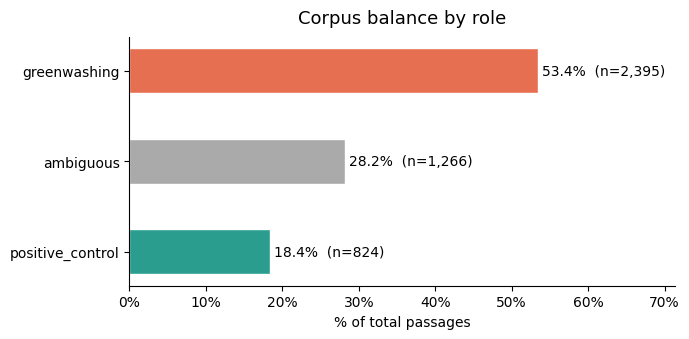

            role  passage_count       pct
positive_control            824 18.372352
       ambiguous           1266 28.227425
    greenwashing           2395 53.400223


In [22]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Load directly from saved CSV
count_df = pd.read_csv(OUT_DIR / 'passage_counts.csv')

# Aggregate passage counts by role
role_df = (
    count_df.groupby('role')['passage_count']
    .sum()
    .reset_index()
)
role_df['pct'] = role_df['passage_count'] / role_df['passage_count'].sum() * 100
role_df = role_df.sort_values('pct', ascending=True)

ROLE_COLORS = {
    'positive_control': '#2a9d8f',
    'edge_case':        '#e9c46a',
    'greenwashing':     '#e76f51',
}
colors = [ROLE_COLORS.get(r, '#aaa') for r in role_df['role']]

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.barh(role_df['role'], role_df['pct'], color=colors, edgecolor='white', height=0.5)

for bar, (_, row) in zip(bars, role_df.iterrows()):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{row['pct']:.1f}%  (n={row['passage_count']:,})",
        va='center', fontsize=10,
    )

ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(0, role_df['pct'].max() + 18)
ax.set_xlabel('% of total passages')
ax.set_title('Corpus balance by role', fontsize=13, pad=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(ROOT / 'results' / 'corpus_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print(role_df[['role', 'passage_count', 'pct']].to_string(index=False))

In [13]:
emissions = tracker.stop()
print(f"Total preprocessing emissions: {emissions:.4f} kg CO2e")
print(f"Saved to: {CARBON_DIR / 'preprocessing_emissions.csv'}")

Total preprocessing emissions: 0.0010 kg CO2e
Saved to: /Users/mandy.sun/green-claims-nlp/results/carbon/preprocessing_emissions.csv
